### Problem 1
Implement serial test and apply to a `samples`

In [1]:
import numpy as np
from scipy import stats

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1
samples = [rng() for _ in range(1000)]

samples_pairs = []
for i in range(0, len(samples) - 1, 2):
    samples_pairs.append((samples[i], samples[i + 1]))

k = 10
x = [pair[0] for pair in samples_pairs]
y = [pair[1] for pair in samples_pairs]

f_obs, x_edges, y_edges = np.histogram2d(x, y, bins=k, range=[[0, 1], [0, 1]])

n_pairs = len(samples_pairs)
f_exp = n_pairs / (k * k)

chi2_stat = np.sum((f_obs - f_exp) ** 2 / f_exp)

df = k * k - 1
p_value = stats.chi2.sf(chi2_stat, df)

print("Chi-square statistic:", chi2_stat)
print("Degrees of freedom:", df)
print("p-value:", p_value)

if p_value < 0.05:
    print("Гипотеза о равномерности отвергается")
else:
    print("Нет оснований отвергать гипотезу о равномерности")







Chi-square statistic: 114.39999999999999
Degrees of freedom: 99
p-value: 0.1380441495447643
Нет оснований отвергать гипотезу о равномерности


Linear congruential generator (LCG) is an algorithm that yields a sequence of pseudo-randomized numbers calculated with a discontinuous piecewise linear equation. The method represents one of the oldest and best-known pseudorandom number generator algorithms. The theory behind them is relatively easy to understand, and they are easily implemented and fast, especially on computer hardware which can provide modulo arithmetic by storage-bit truncation.
$$ z_{i+1} = (az_i + c) \mod m $$

A number $z_0$ called the **seed**. It makes the sequence reproducible.

Let's implement LCG and test it (on practice it is implemented a little bit complicated, but we will use a simple version for educational purposes).

So how do we verify that the sequence does indeed resemble a sample from a uniform distribution?

Let's do a larger sample:

In [4]:
samples = [rng() for _ in range(1000)]

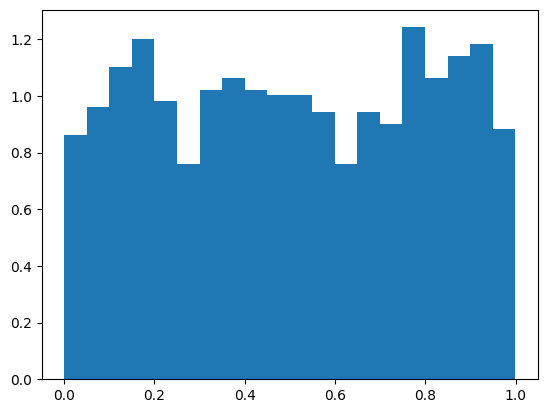

In [5]:
import matplotlib.pyplot as plt

fig = plt.figure()
plt.hist(samples, bins=20, density=True)
plt.show()

Our first "test" is to plot the histogram of the sequence.

The histogram does not seem to contradict the hypothesis of uniformity of distribution, but more accurate quantitative estimates are needed. They are obtained with the help of statistical tests.

In [44]:
# Your code here

The choice of parameters $m$, $a$ and $c$ has a significant impact on the quality of the sequence. If the parameters are chosen unsuccessfully, it can lead to unexpected consequences:

In [4]:
def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m
rng_bad.current = 1

random = [rng_bad() for _ in range(30000)]
print("This sequence looks as random:")
random[:10]

This sequence looks as random:


[3.051897510886192e-05,
 0.00018310965970158577,
 0.0008239871822297573,
 0.003295936156064272,
 0.012359732296317816,
 0.04449496837332845,
 0.15573221957311034,
 0.533938602078706,
 0.8020416363142431,
 0.006802399177104235]

The histogram of the distribution is similar to a uniform distribution:

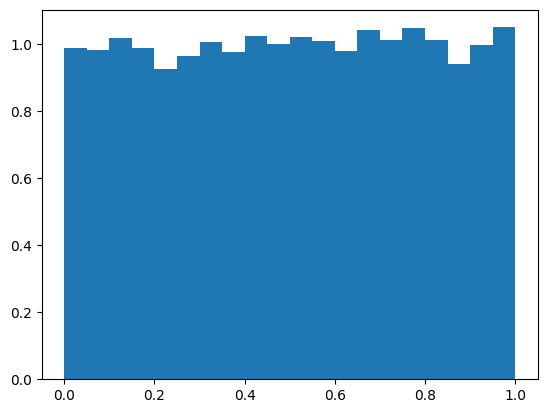

In [31]:
import matplotlib.pyplot as plt
fig = plt.figure()

plt.hist(random, 20, density=True)
plt.show()

However, the series test shows that the points are located on hyperplanes, which does not fit well with the notion of randomness:

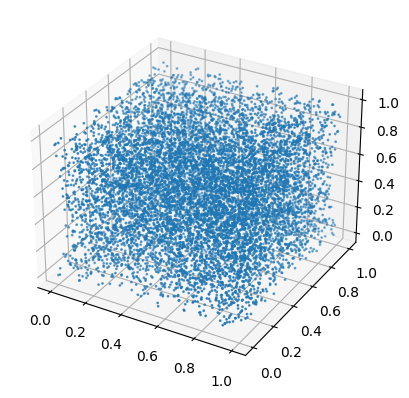

In [17]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(random[::3], random[1::3], random[2::3], s=1)
plt.show()

In [9]:
import plotly.express as px
def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m
rng_bad.current = 1

random = [rng_bad() for _ in range(30000)]
fig = px.scatter_3d(x=random[::3], y=random[1::3], z=random[2::3], opacity=0.1)
fig.update_traces(marker_size = 2)
fig.show()

### Problem 3

Provide a statistical test to show that `rng_bad` has problems but `rng_good` does not.

In [2]:
import numpy as np
from scipy import stats

def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m
rng_bad.current = 1

samples = [rng_bad() for _ in range(30000)]
samples_uniform = np.random.uniform(0, 1, 30000)
samples_triples = []
for i in range(0, len(samples) - 2, 1):
    samples_triples.append((samples[i], samples[i + 1], samples[i+2]))

k = 10
x = [pair[0] for pair in samples_triples]
y = [pair[1] for pair in samples_triples]
z = [pair[2] for pair in samples_triples]

f_obs, edges = np.histogramdd((x, y, z), bins=k, range=[[0, 1], [0, 1],[0,1]])

n_pairs = len(samples_triples)
f_exp = n_pairs / (k * k * k)

chi2_stat = np.sum((f_obs - f_exp) ** 2 / f_exp)

df = k * k * k - 1
p_value = stats.chi2.sf(chi2_stat, df)

print("Chi-square statistic:", chi2_stat)
print("Degrees of freedom:", df)
print("p-value:", p_value)

if p_value < 0.05:
    print("Гипотеза о равномерности отвергается")
else:
    print("Нет оснований отвергать гипотезу о равномерности")


Chi-square statistic: 1241.5493032868858
Degrees of freedom: 999
p-value: 2.151016832918921e-07
Гипотеза о равномерности отвергается


### Problem 4
Simulate a sample of 1000 from a discrete distribution on a set of digits $0, 1, 2, \ldots, 9$ with weights $0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2$. Construct a histogram from the sample. Optimise the algorithm by ordering the weights.

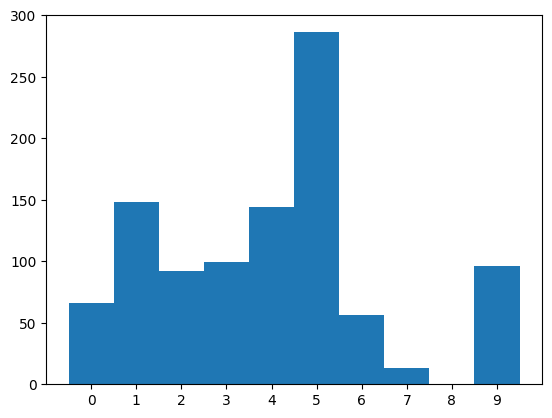

In [31]:
import numpy as np
import matplotlib.pyplot as plt

weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])
values = np.arange(10)

probs = weights / weights.sum()
cdf = np.cumsum(probs)

sample = []

for _ in range(1000):
    u = np.random.uniform(0, 1)
    for i in range(len(cdf)):
        if u < cdf[i]:
            sample.append(values[i])
            break

plt.hist(sample, bins=np.arange(-0.5, 10.5, 1))
plt.xticks(values)
plt.show()


### Problem 5
Simulate a sample of size 1000 from the distribution $\operatorname{Exp}(\lambda)$ using the Inverse transform method. Construct a sample histogram and an accurate plot of the distribution density.

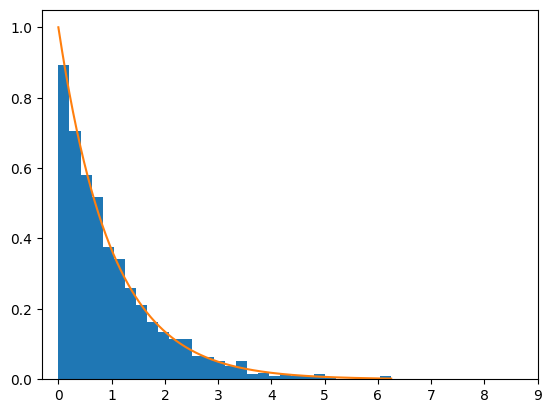

In [41]:
import matplotlib.pyplot as plt
samples_uniform = np.random.uniform(0, 1, 1000)
L = 1
samples_exp = []
for u in samples_uniform:
    x = -np.log(1 - u) / L
    samples_exp.append(x)
plt.hist(samples_exp, bins=30,density=True)
x = np.linspace(0, max(samples_exp), 1000)
y = L * np.exp(-L * x)
plt.plot(x, y)
plt.xticks(values)
plt.show()

### Problem 6
Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $$e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}$$. Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

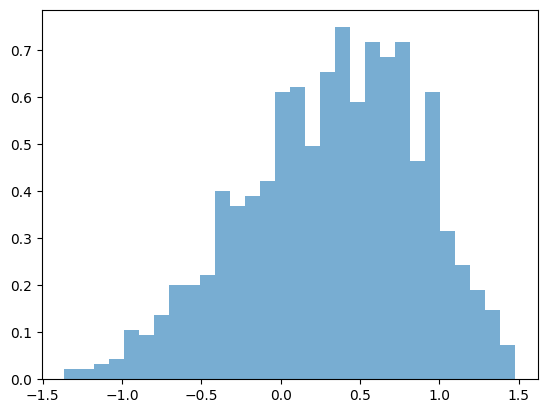

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.exp(x) * np.cos(x)**2

grid = np.linspace(-np.pi/2, np.pi/2, 10000)
M = np.max(f(grid))

samples = []

while len(samples) < 1000:
    x = np.random.uniform(-np.pi/2, np.pi/2)
    y = np.random.uniform(0, M)
    
    if y <= f(x):
        samples.append(x)
plt.hist(samples, bins=30, density=True, alpha=0.6, label='Sample histogram');

### Problem 7
Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

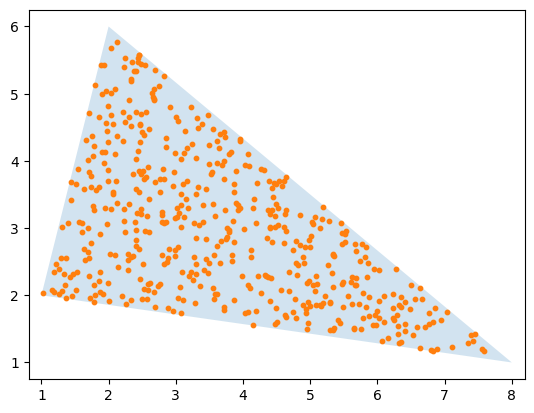

In [45]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([1, 2])
B = np.array([2, 6])
C = np.array([8, 1])

points = []

for _ in range(500):
    u = np.random.rand()
    v = np.random.rand()

    if u + v > 1:
        u = 1 - u
        v = 1 - v

    P = A + u * (B - A) + v * (C - A)
    points.append(P)

points = np.array(points)

plt.figure()
plt.fill([A[0], B[0], C[0]], [A[1], B[1], C[1]], alpha=0.2)
plt.scatter(points[:, 0], points[:, 1], s=10)
plt.axis('equal')
plt.show()

### Problem 8
Model without using the selection method a sample of $500$ points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

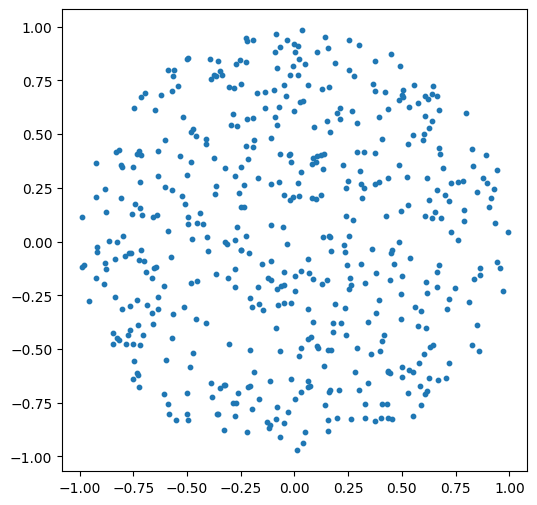

In [48]:
import numpy as np
import matplotlib.pyplot as plt

n = 500

phi = np.random.uniform(0, 2*np.pi, n)
r = np.sqrt(np.random.uniform(0, 1, n))

x = r * np.cos(phi)
y = r * np.sin(phi)

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=10)
plt.axis('equal')
plt.show()

### Problem 6
Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $$e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}$$. Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

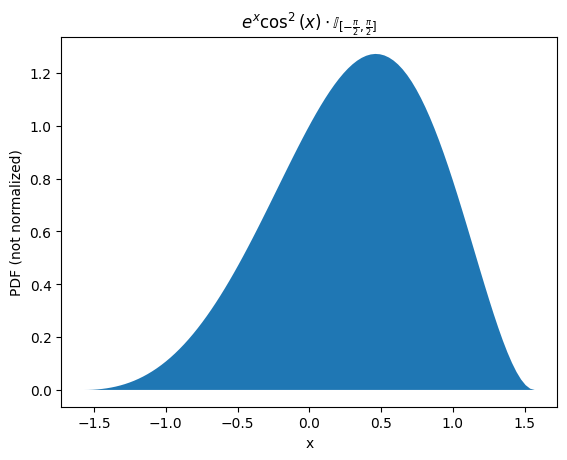

In [52]:
fig = plt.figure()

x = np.linspace(-np.pi/2, np.pi/2, 100)
density = np.exp(x) * np.cos(x) ** 2 # not normalized density!
plt.fill_between(x, 0, density)
plt.ylabel('PDF (not normalized)')
plt.xlabel('x')
plt.title(r'$e^x \cos^2(x) \cdot \mathbb{I}_{[-\frac{\pi}{2}, \frac{\pi}{2}]}$')

plt.show()

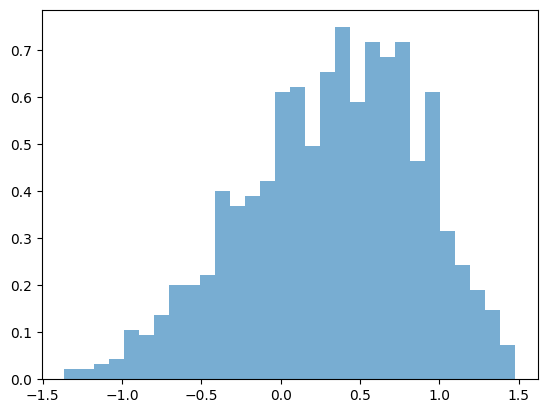

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.exp(x) * np.cos(x)**2

grid = np.linspace(-np.pi/2, np.pi/2, 10000)
M = np.max(f(grid))

samples = []

while len(samples) < 1000:
    x = np.random.uniform(-np.pi/2, np.pi/2)
    y = np.random.uniform(0, M)
    
    if y <= f(x):
        samples.append(x)
plt.hist(samples, bins=30, density=True, alpha=0.6, label='Sample histogram');

### Problem 7
Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

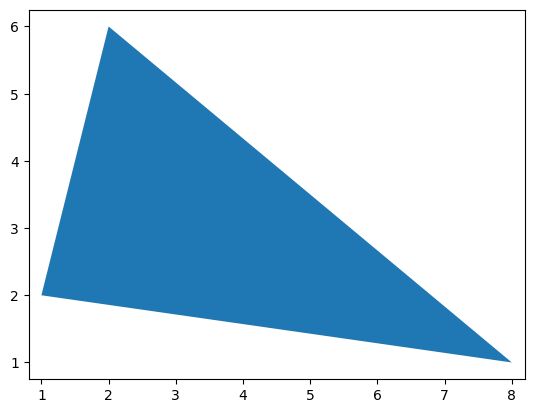

In [54]:
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

fig = plt.figure()

polygon = Polygon(xy=np.array([[1, 2], [2, 6], [8, 1]]), closed=True)
plt.gca().add_collection(PatchCollection([polygon]))
plt.axis('equal')
plt.show()

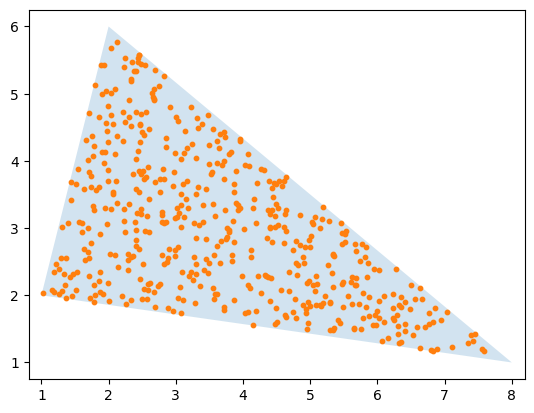

In [45]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([1, 2])
B = np.array([2, 6])
C = np.array([8, 1])

points = []

for _ in range(500):
    u = np.random.rand()
    v = np.random.rand()

    if u + v > 1:
        u = 1 - u
        v = 1 - v

    P = A + u * (B - A) + v * (C - A)
    points.append(P)

points = np.array(points)

plt.figure()
plt.fill([A[0], B[0], C[0]], [A[1], B[1], C[1]], alpha=0.2)
plt.scatter(points[:, 0], points[:, 1], s=10)
plt.axis('equal')
plt.show()

### Problem 8
Model without using the selection method a sample of $500$ points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

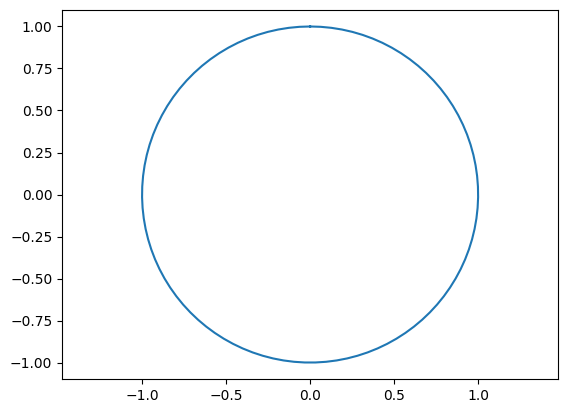

In [56]:
fig = plt.figure()

t = np.linspace(0, 2*np.pi, 100)
plt.plot(np.sin(t), np.cos(t))
plt.axis('equal')
plt.show()

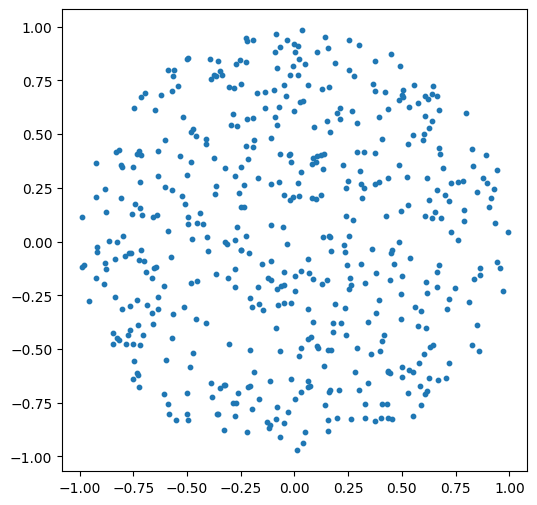

In [48]:
import numpy as np
import matplotlib.pyplot as plt

n = 500

phi = np.random.uniform(0, 2*np.pi, n)
r = np.sqrt(np.random.uniform(0, 1, n))

x = r * np.cos(phi)
y = r * np.sin(phi)

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=10)
plt.axis('equal')
plt.show()

### Problem 9
Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.

Точное среднее:
[4 7]

Выборочное среднее:
[3.99783507 6.90489529]

Точная ковариационная матрица:
[[20 -4]
 [-4 40]]

Выборочная ковариационная матрица:
[[20.5669778  -4.06552706]
 [-4.06552706 40.12722869]]


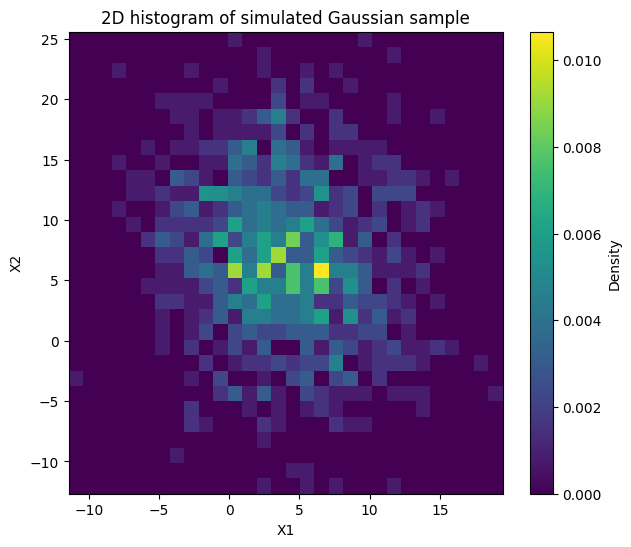

In [3]:
import numpy as np
import matplotlib.pyplot as plt

mu = np.array([4, 7])
Sigma = np.array([[20, -4],
                  [-4, 40]])

n = 1000

z1_list = []
z2_list = []

while len(z1_list) < n:
    u = np.random.uniform(-1, 1)
    v = np.random.uniform(-1, 1)
    s = u**2 + v**2

    if s == 0 or s >= 1:
        continue
    z1_list.append(u * np.sqrt(-2 * np.log(s) / s))
    z2_list.append(v * np.sqrt(-2 * np.log(s) / s))

Z = np.vstack((z1_list, z2_list)) 

A = np.linalg.cholesky(Sigma)
X = (A @ Z).T + mu 

sample_mean = np.mean(X, axis=0)
sample_cov = np.cov(X, rowvar=False)

print("Точное среднее:")
print(mu)
print("\nВыборочное среднее:")
print(sample_mean)

print("\nТочная ковариационная матрица:")
print(Sigma)
print("\nВыборочная ковариационная матрица:")
print(sample_cov)

plt.figure(figsize=(7, 6))
plt.hist2d(X[:, 0], X[:, 1], bins=30, density=True)
plt.colorbar(label='Density')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('2D histogram of simulated Gaussian sample')
plt.show()